In [1]:
from misc import *
import constant

# upto 5 long track candidates isMuon
LTRACK5_FILE_PATH = "/dice/projects/LHCb/PbPb_MSCi/isMuon_Tr1_5_B2JpsiK_PbPb/LeadLead_B2JpsiKTuple_all.root"
DEFAULT_TREE_NAME = "B2JpsiKTuple/DecayTree"

df = load_root(LTRACK5_FILE_PATH, DEFAULT_TREE_NAME)
df = df[df["Kplus_isMuon"] == False]
df = df[(constant.JPSI_MASS-50 <= df["J_psi_1S_M"]) & (df["J_psi_1S_M"] <= constant.JPSI_MASS+50)]

In [2]:
import zfit
import zfit.plot

/software/ai21208/Code/venv/lib/python3.12/site-packages/zfit/__init__.py:60: UserWarning: TensorFlow warnings are by default suppressed by zfit. In order to show them, set the environment variable ZFIT_DISABLE_TF_WARNINGS=0. In order to suppress the TensorFlow warnings AND this warning, set ZFIT_DISABLE_TF_WARNINGS=1.
  warnings.warn(
2025-01-28 16:25:53.695903: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1738081553.711745 4108137 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1738081553.716889 4108137 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
background_range = (5500, 6000)
background_masses_series = df[(df["Bplus_M"] > background_range[0]) & (df["Bplus_M"] < background_range[1])]["Bplus_M"]

background_mass = zfit.Space("Bplus_M", limits=background_range)
lambda_ = zfit.Parameter("lambda", -0.001, floating=True)

background_yield = zfit.Parameter("bkg_yield", 300)

data = zfit.Data.from_pandas(background_masses_series, obs=background_mass)

background_model = zfit.pdf.Exponential(lam=lambda_, obs=background_mass)

nll = zfit.loss.UnbinnedNLL(model=background_model, data=data)

minimizer = zfit.minimize.Minuit()
result = minimizer.minimize(loss=nll)

print(result)


2025-01-28 16:25:57.815417: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_SYSTEM_DRIVER_MISMATCH: system has unsupported display driver / cuda driver combination
2025-01-28 16:25:57.815556: E external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:262] kernel version 555.42.6 does not match DSO version 570.86.15 -- cannot find working devices in this configuration


FitResult of
<UnbinnedNLL model=[<zfit.<class 'zfit.models.basic.Exponential'>  params=[lambda, lambda]] data=[<zfit.Data: Data obs=('Bplus_M',) shape=(277, 1)>] constraints=[]> 
with
<Minuit Minuit tol=0.001>

╒═════════╤═════════════╤══════════════════╤═════════╤══════════════════════════════╕
│  valid  │  converged  │  param at limit  │   edm   │   approx. fmin (full | opt.) │
╞═════════╪═════════════╪══════════════════╪═════════╪══════════════════════════════╡
│  True   │    True     │      False       │ 1.7e-07 │           1710.91 |  9997.57 │
╘═════════╧═════════════╧══════════════════╧═════════╧══════════════════════════════╛

Parameters
name      value  (rounded)    at limit
------  ------------------  ----------
lambda         -0.00193278       False


Histogram not saved to file


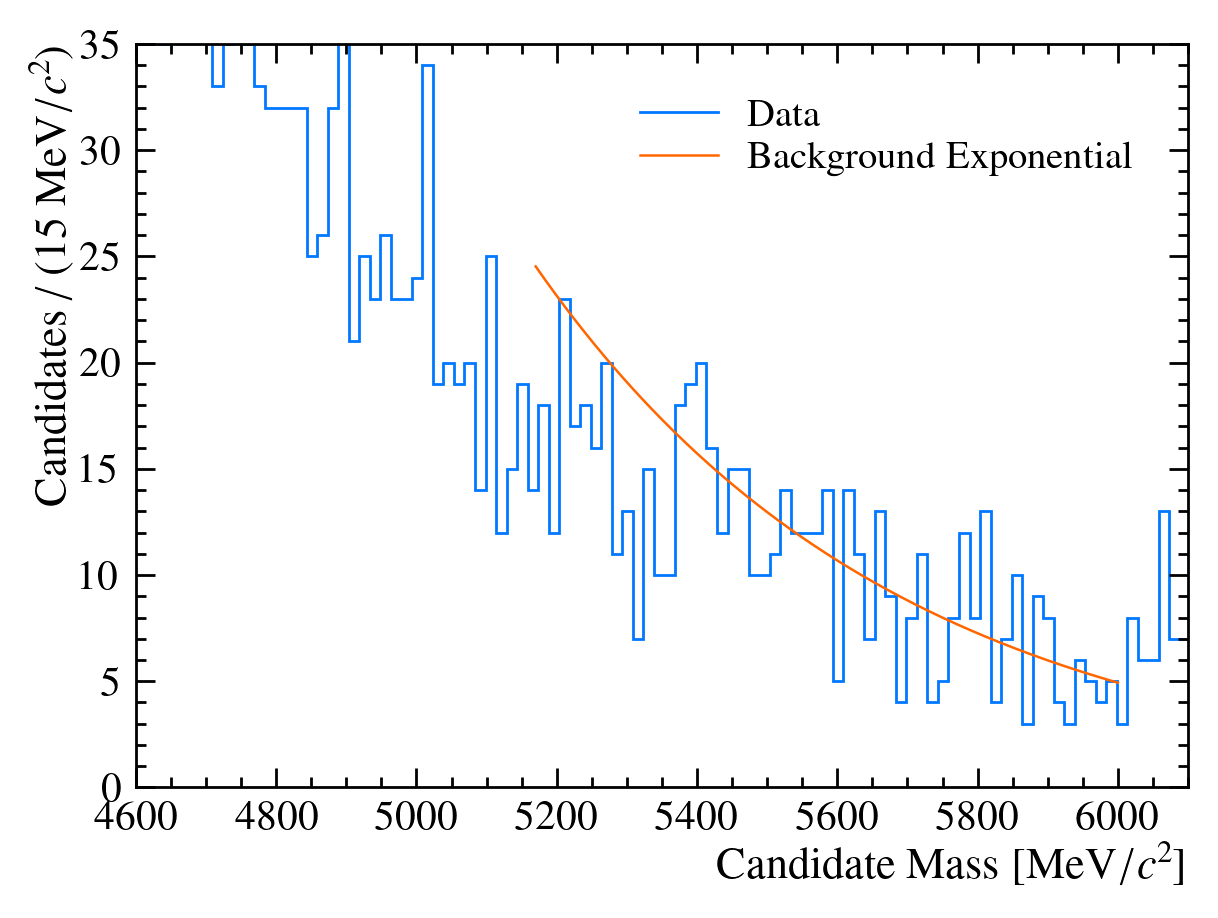

In [4]:
x = np.linspace(*background_mass.limit1d, num=1000)

bin_width = 15
fig, ax = histogram_fig(
    [p := HistogramPlot(df["Bplus_M"], "Data", bins=bin_width)],
    False,
    unit_tex=r"\mathrm{MeV}/c^2",
    xlabel="Candidate Mass",
    xlim=[4600, 6100],
    ylim=[0,35]
)

scale=bin_width*int(data.n_events)
x = np.linspace(5170, 6000, 300)

ax.plot(x, background_model.pdf(x)*scale, label="Background Exponential", linewidth=1.8)
ax.legend()

In [5]:
limits = (5000, 6000)

# Define the observable (entire range of the data)
obs = zfit.Space("Bplus_M", limits=limits)

# Define the Gaussian (signal) component
mu = zfit.Parameter("mu", constant.BPLUS_MASS, floating=False)  # Fixed mean
sigma = zfit.Parameter("sigma", 10, 5, 50)  # Floating sigma
gauss = zfit.pdf.Gauss(mu=mu, sigma=sigma, obs=obs)

# Define the Exponential (background) component
lambda_ = zfit.Parameter("lambda", -0.001, -0.1, 0.0)  # Floating slope
expo = zfit.pdf.Exponential(lam=lambda_, obs=obs)

# Define the yields (N_s and N_bkg)
N_s = zfit.Parameter("N_s", 5, 0, 10000)  # Floating signal yield
N_bkg = zfit.Parameter("N_bkg", 300, 0, 20000)  # Floating background yield

# Combine the models with yields
signal_pdf = gauss.create_extended(N_s)
background_pdf = expo.create_extended(N_bkg)
P_tot = zfit.pdf.SumPDF([signal_pdf, background_pdf])

data = zfit.Data.from_pandas(df["Bplus_M"], obs=obs)

# Perform the fit
nll = zfit.loss.UnbinnedNLL(model=P_tot, data=data)
minimizer = zfit.minimize.Minuit()
result = minimizer.minimize(nll)

Histogram not saved to file
Histogram not saved to file


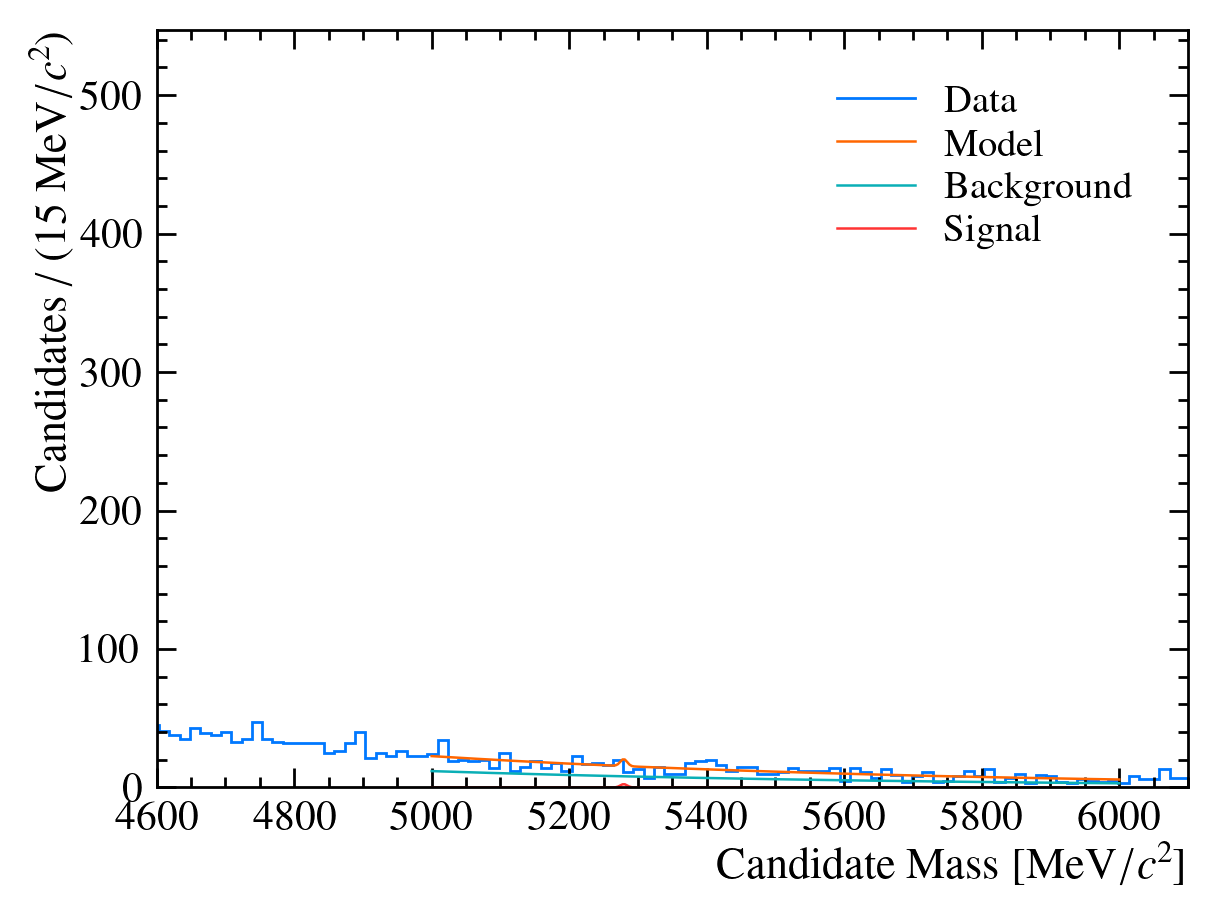

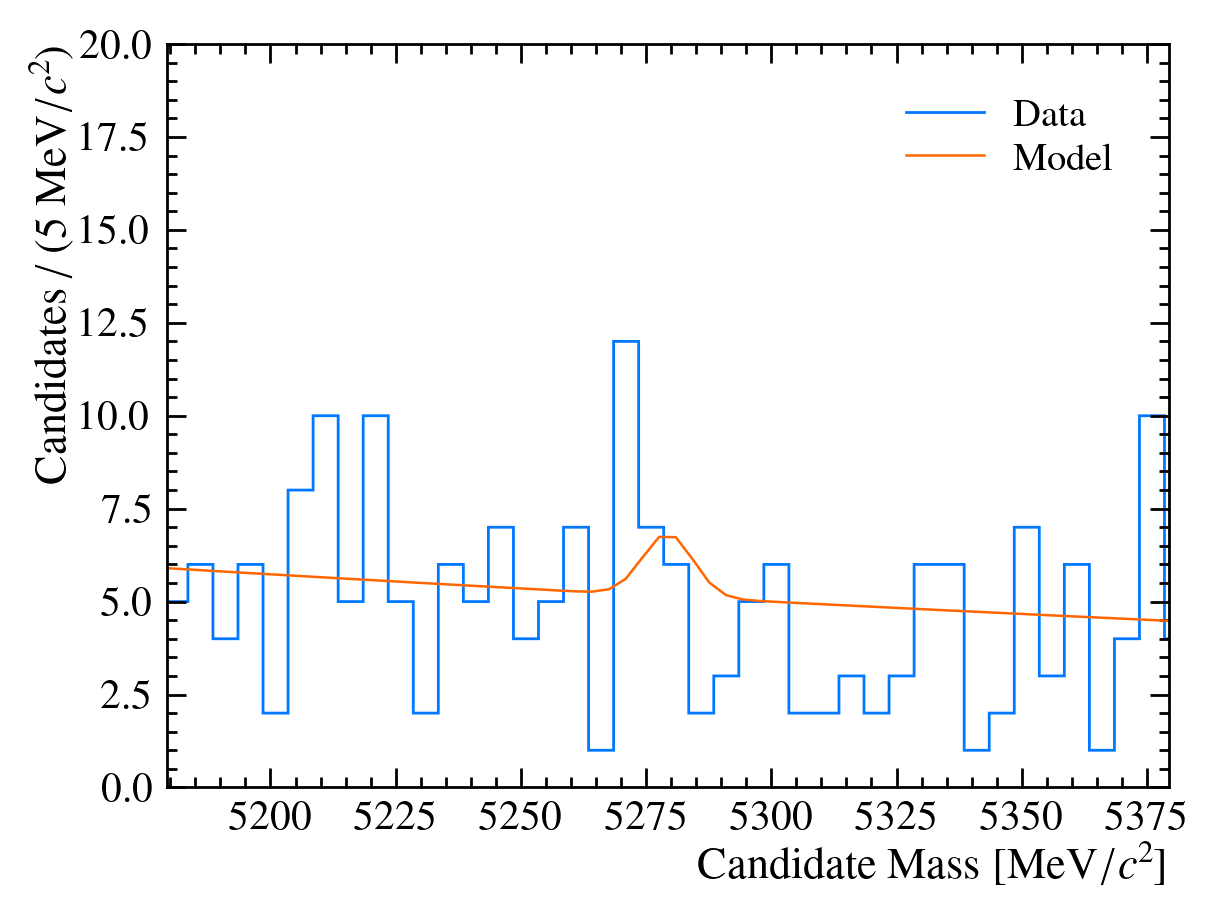

In [6]:
bin_width = 15
fig1, ax1 = histogram_fig(
    [p := HistogramPlot(df["Bplus_M"], "Data", bins=bin_width)],
    False,
    unit_tex=r"\mathrm{MeV}/c^2",
    xlabel="Candidate Mass",
    xlim=[4600, 6100],
    # ylim=[0,100],
)


x = np.linspace(*limits, 300)
ax1.plot(x, P_tot.pdf(x)*bin_width*int(data.n_events), label="Model", linewidth=1.8)
ax1.plot(x, background_pdf.pdf(x)*bin_width*int(N_bkg), label="Background", linewidth=1.8)
ax1.plot(x, signal_pdf.pdf(x)*bin_width*int(N_s), label="Signal", linewidth=1.8)
ax1.legend()

bin_width = 5
fig2, ax2 = histogram_fig(
    [p := HistogramPlot(df["Bplus_M"], "Data", bins=bin_width)],
    False,
    unit_tex=r"\mathrm{MeV}/c^2",
    xlabel="Candidate Mass",
    ylim=[0,20],
    preset="Bplus Mass"
)

scale=bin_width*int(data.n_events)
x = np.linspace(*limits, 300)
ax2.plot(x, P_tot.pdf(x)*scale, label="Model", linewidth=1.8)
ax2.legend()